# <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 35px 35px;">Сustomer churn</p>

Предстоит научитсья моделировать отток клиентов телеком компании. Эта задача очень важна на практике и алгоритмы для ее решения используются в реальных телеком компаниях, если мы знаем, что клиент собирается уйти от нас, то мы попытаться удержать его, предложив какие-то бонусы.

## <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 25px 5px;">Table of Contents</p>

[1. Loading and reading data](#1.-Loading-and-reading-data)  
* [1.1. Import library](#1.1.-Import-library)  
* [1.2. Function list](#1.2.-Function-list)  
* [1.3. Load data](#1.3.-Load-data)  
* [1.4. Info data](#1.4.-Info-data)  

[2. EDA](#2.-EDA)  
* [2.1. Distribution data](#2.1.-Distribution-data) 
* [2.2. Clustering](#2.2.-Clustering)
* [2.3. Feature correlation](#2.3.-Feature-correlation)  

[3. Datasets creation](#3.-Datasets-creation)

[4. Selection of models](#4.-Selection-of-models)
* [4.1. Catboost](#4.1.-Catboost)  
* [4.2. LGBM](#4.2.-LGBM)  
* [4.3. XGBoost](#4.3.-XGBoost)  
* [4.4. LogisticRegression](#4.4.-LogisticRegression) 
* [4.5. Ensemble](#4.5.-Ensemble) 

[5. Best Model Submission](#5.-Best-Model-Submission)

## <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 25px 5px;">1. Loading and reading data</p>

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">1.1. Import library</p>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/advanced-dls-spring-2021/submission.csv
/kaggle/input/advanced-dls-spring-2021/train.csv
/kaggle/input/advanced-dls-spring-2021/test.csv


In [2]:
import pandas as pd
import numpy as np
import time

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import *
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score, silhouette_score

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit, GridSearchCV
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve, select_threshold
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

SEED = 202301
palitra = dict(blue='#1d7990', indigo='#032733', bardo='#641216')

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">1.2. Function list</p>

In [3]:
# info_describe_nan_duplicates_head
def def_info(df):
    print('Table shapes:', df.shape)
    print('************************************')
    print()
    print('General information:')
    print(df.info())
    print('************************************')
    print()
    print('5 lines:')
    display(df.sample(5))
    print('************************************')
    print()
    print('Share of NaN-s:')
    nulls_df = pd.DataFrame(data=np.array(df.isna().mean()), index=df.columns, columns=['nan'])
    print(nulls_df[nulls_df['nan'] > 0].sort_values(by='nan', ascending=False))
    print('************************************')
    print()
    print('Share of duplicatesх:', df.duplicated().mean())
    print('************************************')
    print() 
    print('Describe features:')
    display(df.describe(include='object').T)
    display(df.describe().T)

# data distribution_hist_box
def make_boxplot(df, column):
    _, [axs_hist, axs_box] = plt.subplots(2, 1, figsize=(10, 4), 
                                         sharex=True,
                                         gridspec_kw=dict(height_ratios=[4,.8]))
    hist = sns.histplot(data=df, x=column, kde=True, ax=axs_hist, color=palitra['indigo'])
    box = sns.boxplot(data=df, x=column, orient='h', ax=axs_box, color=palitra['blue'])
    hist.set(title=f'Distribution of {column}',
             ylabel='Number of objects');
    
# table share by column to target
def make_table_rote_target(data, column, target):
    table = (data.groupby(column)[target].agg(['sum', 'count'])
    .assign(share = lambda x: x['sum'] / x['count'])
    ).sort_values(by='share', ascending=False).style.background_gradient(low=0.1, cmap='YlOrRd')
    return table

# graph roc_curve
def make_roc_curve(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, linestyle='-', color=palitra['blue'])
    plt.plot([0, 1], [0, 1], linestyle='--', color=palitra['bardo'])
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-CURVE')
    plt.show()
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))

# distribution of column according to target variable
def make_plot_distribution(df, col, target):
    fig = px.histogram(train, x=col, color=target,
                       marginal='box',opacity=0.8,nbins=100,
                       barmode='group',histfunc='count', color_discrete_sequence=[palitra['blue'], palitra['bardo']])

    fig.update_layout(font_family='Arial',
                      title=dict(text=f'Distribution of {col} according to {target} variable',x=0.53,y=0.95),
                      xaxis_title_text=col,
                      yaxis_title_text='Count',
                      bargap=0.3)
    fig.show()
# dendogram    
def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical clustering dendrogram')
        plt.xlabel('Cluster size')
        plt.ylabel('Distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata
func = ['def_info', 'make_table_rote_target', 'fancy_dendrogram', 
        'make_plot_distribution', 'make_roc_curve', 'make_boxplot']

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">1.3. Load data</p>

In [4]:
submission = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/submission.csv')
train = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/train.csv')
test = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/test.csv')

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">1.4. Info data</p>

In [5]:
def_info(train)

Table shapes: (5282, 20)
************************************

General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
3705,63,99.90,6137,Female,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,One year,No,Bank transfer (automatic),1
2546,27,20.25,538.2,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),0
181,25,89.50,2196.15,Male,1,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,1
1723,60,105.90,6401.25,Female,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,0
2065,25,95.90,2448.75,Male,0,No,Yes,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,1


************************************

Share of NaN-s:
Empty DataFrame
Columns: [nan]
Index: []
************************************

Share of duplicatesх: 0.0026505111700113595
************************************

Describe features:


,count,unique,top,freq
TotalSpent,5282,4978,,9
Sex,5282,2,Male,2655
HasPartner,5282,2,No,2705
HasChild,5282,2,No,3676
HasPhoneService,5282,2,Yes,4761
HasMultiplePhoneNumbers,5282,3,No,2511
HasInternetService,5282,3,Fiber optic,2341
HasOnlineSecurityService,5282,3,No,2612
HasOnlineBackup,5282,3,No,2332
HasDeviceProtection,5282,3,No,2317


,count,mean,std,min,25%,50%,75%,max
ClientPeriod,5282.0,32.397009,24.550326,0.00,9.0000,29.0,55.00,72.00
MonthlySpending,5282.0,64.924754,30.176464,18.25,35.4625,70.4,90.05,118.75
IsSeniorCitizen,5282.0,0.159409,0.366092,0.00,0.0000,0.0,0.00,1.00
Churn,5282.0,0.262022,0.439776,0.00,0.0000,0.0,1.00,1.00


In [6]:
def_info(test)

Table shapes: (1761, 19)
************************************

General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              1761 non-null   int64  
 1   MonthlySpending           1761 non-null   float64
 2   TotalSpent                1761 non-null   object 
 3   Sex                       1761 non-null   object 
 4   IsSeniorCitizen           1761 non-null   int64  
 5   HasPartner                1761 non-null   object 
 6   HasChild                  1761 non-null   object 
 7   HasPhoneService           1761 non-null   object 
 8   HasMultiplePhoneNumbers   1761 non-null   object 
 9   HasInternetService        1761 non-null   object 
 10  HasOnlineSecurityService  1761 non-null   object 
 11  HasOnlineBackup           1761 non-null   object 
 12  HasDeviceProtection       1761 non

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
588,1,90.55,90.55,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check
145,20,68.70,1416.2,Male,0,No,No,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Electronic check
1562,7,20.25,129.15,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check
700,25,20.60,541.5,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check
1760,72,65.60,4566.5,Male,0,No,No,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)


************************************

Share of NaN-s:
Empty DataFrame
Columns: [nan]
Index: []
************************************

Share of duplicatesх: 0.0017035775127768314
************************************

Describe features:


,count,unique,top,freq
TotalSpent,1761,1710,19.55,4
Sex,1761,2,Male,900
HasPartner,1761,2,No,936
HasChild,1761,2,No,1257
HasPhoneService,1761,2,Yes,1600
HasMultiplePhoneNumbers,1761,3,No,879
HasInternetService,1761,3,Fiber optic,755
HasOnlineSecurityService,1761,3,No,886
HasOnlineBackup,1761,3,No,756
HasDeviceProtection,1761,3,No,778


,count,mean,std,min,25%,50%,75%,max
ClientPeriod,1761.0,32.293583,24.593736,0.00,9.00,29.00,56.0,72.00
MonthlySpending,1761.0,64.272601,29.832517,18.55,35.65,70.05,89.4,117.35
IsSeniorCitizen,1761.0,0.170358,0.376054,0.00,0.00,0.00,0.0,1.00


In [7]:
# удалим дубли 
train.drop_duplicates(inplace=True)

In [8]:
# изменим тип данных у колонки TotalSpent на float
train.TotalSpent = train.TotalSpent.replace(' ', '0').astype('float')
test.TotalSpent = test.TotalSpent.replace(' ', '0').astype('float')

In [9]:
# выведем уникальные значения в колонках типа object
for col in train.select_dtypes(include='object').columns:
    print(f'{col} {list(train[col].unique())}')

Sex ['Male', 'Female']
HasPartner ['Yes', 'No']
HasChild ['Yes', 'No']
HasPhoneService ['Yes', 'No']
HasMultiplePhoneNumbers ['No', 'Yes', 'No phone service']
HasInternetService ['No', 'Fiber optic', 'DSL']
HasOnlineSecurityService ['No internet service', 'No', 'Yes']
HasOnlineBackup ['No internet service', 'No', 'Yes']
HasDeviceProtection ['No internet service', 'No', 'Yes']
HasTechSupportAccess ['No internet service', 'Yes', 'No']
HasOnlineTV ['No internet service', 'No', 'Yes']
HasMovieSubscription ['No internet service', 'No', 'Yes']
HasContractPhone ['One year', 'Two year', 'Month-to-month']
IsBillingPaperless ['No', 'Yes']
PaymentMethod ['Mailed check', 'Credit card (automatic)', 'Electronic check', 'Bank transfer (automatic)']


## <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 25px 5px;">2. EDA</p>

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">2.1. Distribution data</p>

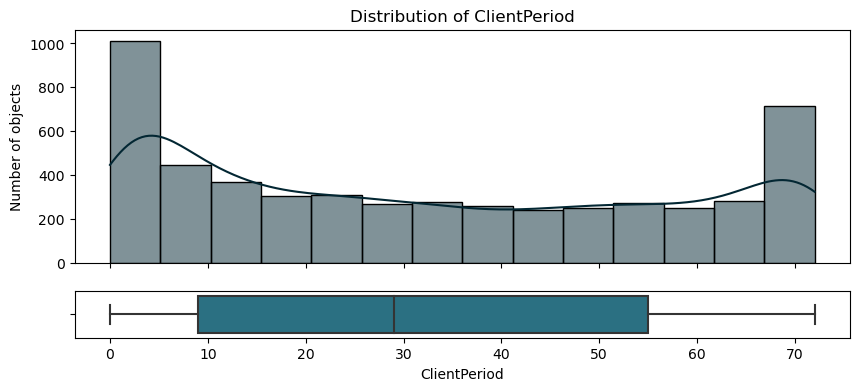

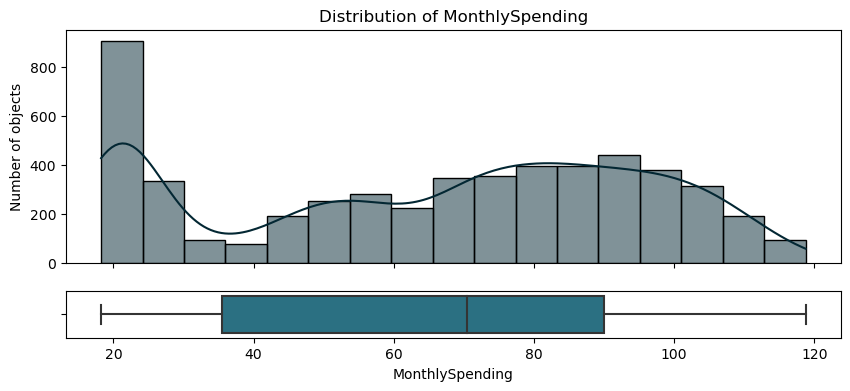

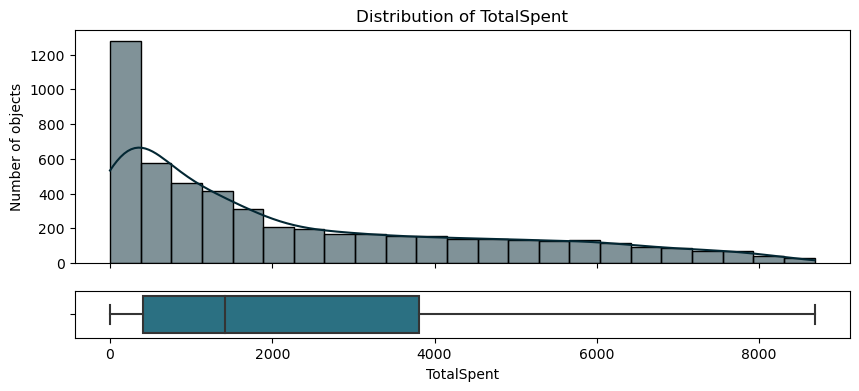

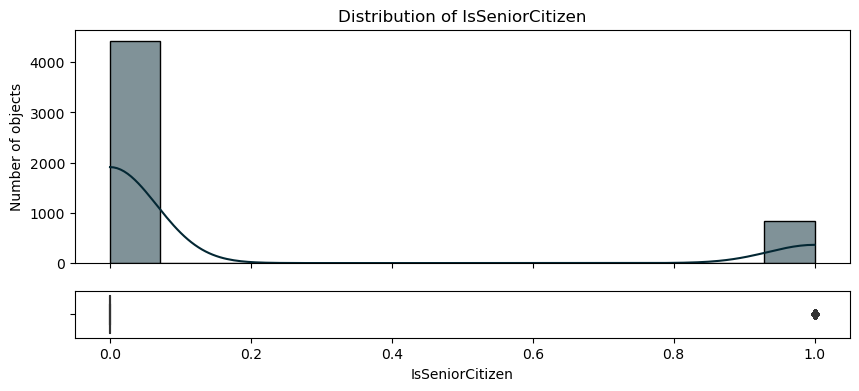

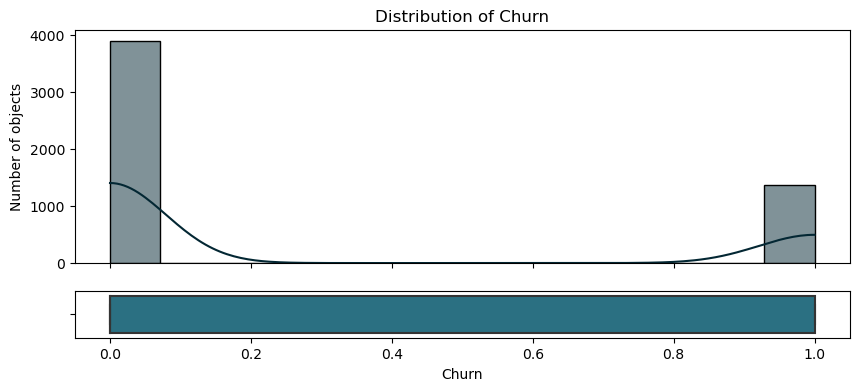

In [10]:
for col in train.select_dtypes(include='number'):
    make_boxplot(train, col)

**Выбросов в числовых данных нет, имеем дисбаланс даннынх по целевому признаку Churn, это нужно будет учесть при обучении/выборе наших моделей.**

In [11]:
for col in train.select_dtypes(include='object'):
    make_plot_distribution(train, col, 'Churn')

In [12]:
for col in train.select_dtypes(include='object'):
    display(make_table_rote_target(train, col, 'Churn'))

,sum,count,share
Sex,,,
Female,693,2621,0.264403
Male,681,2647,0.257272


,sum,count,share
HasPartner,,,
No,871,2691,0.323671
Yes,503,2577,0.195188


,sum,count,share
HasChild,,,
No,1128,3662,0.308028
Yes,246,1606,0.153176


,sum,count,share
HasPhoneService,,,
Yes,1245,4747,0.262271
No,129,521,0.247601


,sum,count,share
HasMultiplePhoneNumbers,,,
Yes,635,2250,0.282222
No phone service,129,521,0.247601
No,610,2497,0.244293


...

,sum,count,share
HasOnlineTV,,,
No,692,2091,0.330942
Yes,602,2042,0.294809
No internet service,80,1135,0.070485


,sum,count,share
HasMovieSubscription,,,
No,697,2073,0.336228
Yes,597,2060,0.289806
No internet service,80,1135,0.070485


,sum,count,share
HasContractPhone,,,
Month-to-month,1221,2906,0.420165
One year,120,1082,0.110906
Two year,33,1280,0.025781


,sum,count,share
IsBillingPaperless,,,
Yes,1038,3140,0.330573
No,336,2128,0.157895


,sum,count,share
PaymentMethod,,,
Electronic check,788,1780,0.442697
Mailed check,226,1186,0.190556
Bank transfer (automatic),195,1159,0.168248
Credit card (automatic),165,1143,0.144357


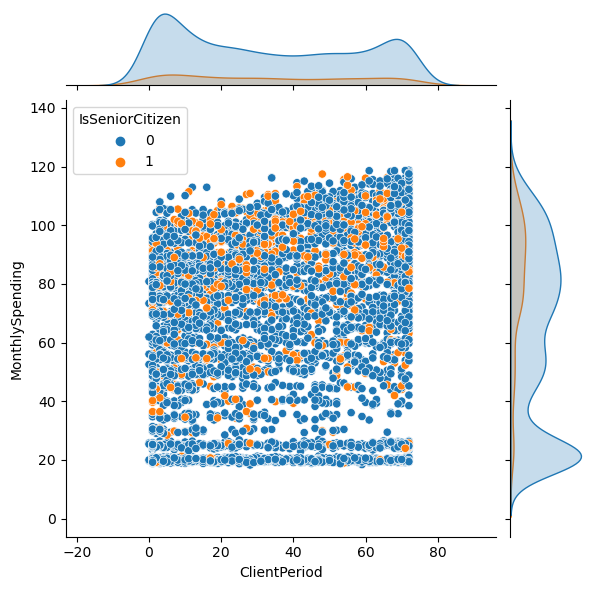

In [13]:
sns.jointplot(data=train, x="ClientPeriod", y="MonthlySpending", hue='IsSeniorCitizen');

In [14]:
# заменим нулевые значения на 1
train.ClientPeriod = train.ClientPeriod.apply(lambda x: 1 if x == 0 else x)

### Портрет клиента, который уходит

1. Нет партнера
2. Нет детей
3. Использует оптоволокно
4. Нет онлайн-сервиса безопасности
5. Не выполняется резервное копирование
6. Нет защиты устройства
7. Нет подключения к тех.поддержке
8. Нет онлайн-ТВ
9. Нет подписки на фильмы
10. Тип договора месячный
11. Пользуется безбумажными счетами и электронной оплаттой

**У нас есть бинарные признаки представленные как категориальные HasPartner, HasChild, HasPhoneService, IsBillingPaperless и другие.**

In [15]:
def make_features(df):
    df_new = df.copy()
#     приведем колонки к бинарному виду
    for col in list(set(df_new.select_dtypes(include='object').columns) - set(['Sex','HasInternetService','HasContractPhone','PaymentMethod'])):
        df_new[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)
#     заменим тип данных на category
    for col in list(df_new.select_dtypes(include='object').columns):
        df_new[col] = df_new[col].astype('category')
#     заменим текстовые значения в категориальных столбцах на числовые
    cat_features = list(df_new.select_dtypes(include='category').columns)
    df_new[cat_features] = df_new[cat_features].astype('category').apply(lambda x: x.cat.codes)

    return df_new

def make_my_pipline(df):
    new_df = df.copy()
    columns = list(new_df.columns)
    new_df[columns] = StandardScaler().fit(new_df[columns]).transform(new_df[columns])
    return new_df

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">2.2. Clustering</p>

In [16]:
clust_df = train.query('Churn == 1')
clust_df = pd.concat([clust_df, train.query('Churn == 0').head(1374)]).reset_index(drop=True)
cols = ['HasPartner', 'HasChild', 'HasInternetService', 'HasOnlineSecurityService',
        'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV',
       'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod', 'Churn']
clust_df = make_features(clust_df)
clust_df.sample(5)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
2094,13,70.45,849.10,1,1,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0
1721,67,19.45,1195.95,1,0,0,0,1,0,2,0,0,0,0,0,0,1,1,3,0
797,1,70.90,70.90,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,3,1
2695,67,111.05,7321.05,1,0,1,0,1,0,1,1,1,1,1,1,1,2,1,2,0
172,3,74.40,229.55,1,0,0,0,1,1,1,0,0,0,0,0,0,0,1,2,1


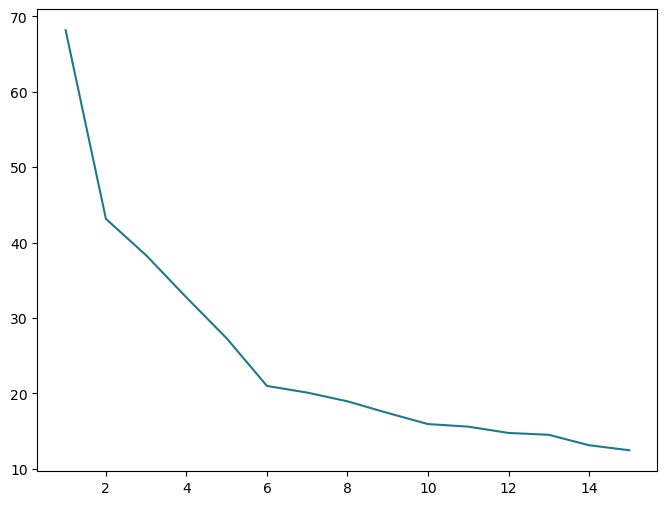

In [17]:
link = linkage(clust_df[cols], method='ward', metric='euclidean')
last = link[-15:, 2][::-1]
idxs = np.arange(1, len(last) + 1)
plt.figure(figsize=(8, 6))
plt.plot(idxs, last, color=palitra['blue'])
plt.show()

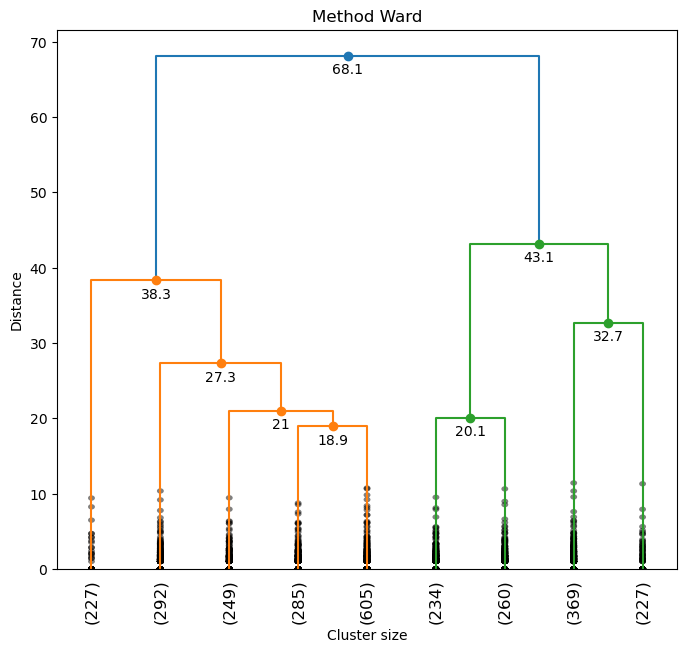

In [18]:
n_clust = 9

plt.figure(figsize=(8, 7))
fancy_dendrogram(link, truncate_mode='lastp', p=n_clust, 
                 leaf_rotation=90, leaf_font_size=12, show_contracted=True, annotate_above=10)
plt.title('Method Ward')
# plt.savefig(f'Method Ward n_cluster {n_clust}.jpeg', dpi=150, bbox_inches='tight')
plt.show()

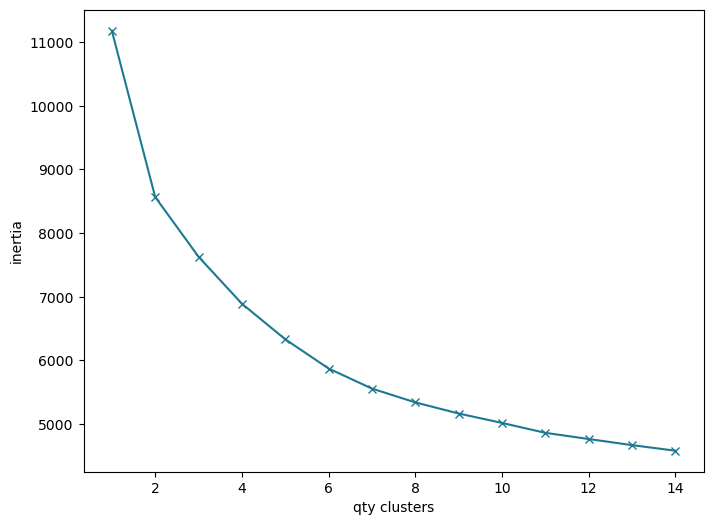

In [19]:
distortion = []
K = range(1, 15)
for k in K:
    km = KMeans(n_clusters=k, random_state=SEED, max_iter=300)
    km.fit(clust_df[cols])
    distortion.append(km.inertia_) 
plt.figure(figsize=(8, 6))
plt.plot(K, distortion, 'bx-', color=palitra['blue'])
plt.xlabel('qty clusters')
plt.ylabel('inertia')
plt.show()

In [20]:
best_n_clusters = 0
best_ari = 0
best_silh = 0
for n in range(1, 16):
    km = KMeans(n_clusters=n, random_state=SEED, max_iter=300)
    km.fit(clust_df)
    if adjusted_rand_score(clust_df['Churn'], km.labels_) > best_ari:
        best_ari = adjusted_rand_score(clust_df['Churn'], km.labels_)
        best_silh = silhouette_score(clust_df, km.labels_)
        best_n_clusters = n
best_ari, best_silh, best_n_clusters

(0.03362723165423364, 0.7061642823655826, 2)

In [21]:
clust_df['ward'] = fcluster(link, best_n_clusters, criterion='maxclust')

In [22]:
km = KMeans(n_clusters=best_n_clusters, random_state=SEED, max_iter=300)
km.fit(clust_df[cols])
centers = km.cluster_centers_
clust_df['kmean'] = km.labels_

In [23]:
clust_df.groupby(['ward'])['Churn'].sum(), clust_df.groupby(['kmean'])['Churn'].sum()

(ward
 1    1050
 2     324
 Name: Churn, dtype: int64,
 kmean
 0     280
 1    1094
 Name: Churn, dtype: int64)

In [24]:
result = clust_df.groupby(['kmean', 'Churn'])[cols].mean()
result['qty'] = clust_df.groupby(['kmean', 'Churn']).size().values
result.query('Churn == 1')

,,HasPartner,HasChild,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,PaymentMethod,Churn,qty
kmean,Churn,,,,,,,,,,,,,
0,1,0.539286,0.275000,0.792857,0.278571,0.407143,0.439286,0.292857,0.539286,0.564286,0.421429,0.328571,1.0,280
1,1,0.321755,0.154479,0.815356,0.118830,0.240402,0.255027,0.133455,0.412249,0.401280,0.062157,2.127057,1.0,1094


In [25]:
cols = ['HasPartner', 'HasChild', 'HasInternetService', 'HasOnlineSecurityService',
        'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV',
       'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod']

In [26]:
cluster_centers = np.array(result.query('Churn == 1')[cols])

In [27]:
km = KMeans(n_clusters=best_n_clusters, random_state=SEED, max_iter=300, init=cluster_centers)
km.fit(make_features(test[cols]))
test['kmean'] = km.labels_
km.fit(make_features(train[cols]))
train['kmean'] = km.labels_

In [28]:
train

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn,kmean
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0,1
1,72,25.85,1872.20,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0,0
2,1,75.90,75.90,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1,1
3,32,79.30,2570.00,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0,1
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,Male,0,No,No,No,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,No,Electronic check,0,1
5278,50,44.45,2188.45,Male,0,Yes,No,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0,0
5279,1,55.05,55.05,Male,0,No,No,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check,0,1
5280,29,76.00,2215.25,Female,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),0,1


### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">2.3. Feature correlation</p>

In [29]:
train.corr().style.background_gradient(low=0.1, cmap='YlOrRd')

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Churn,kmean
ClientPeriod,1.000000,0.248026,0.826172,0.010746,-0.348954,-0.474227
MonthlySpending,0.248026,1.000000,0.651984,0.215061,0.185915,-0.133149
TotalSpent,0.826172,0.651984,1.000000,0.094194,-0.198164,-0.406883
IsSeniorCitizen,0.010746,0.215061,0.094194,1.000000,0.157751,0.036046
Churn,-0.348954,0.185915,-0.198164,0.157751,1.000000,0.234815
kmean,-0.474227,-0.133149,-0.406883,0.036046,0.234815,1.000000


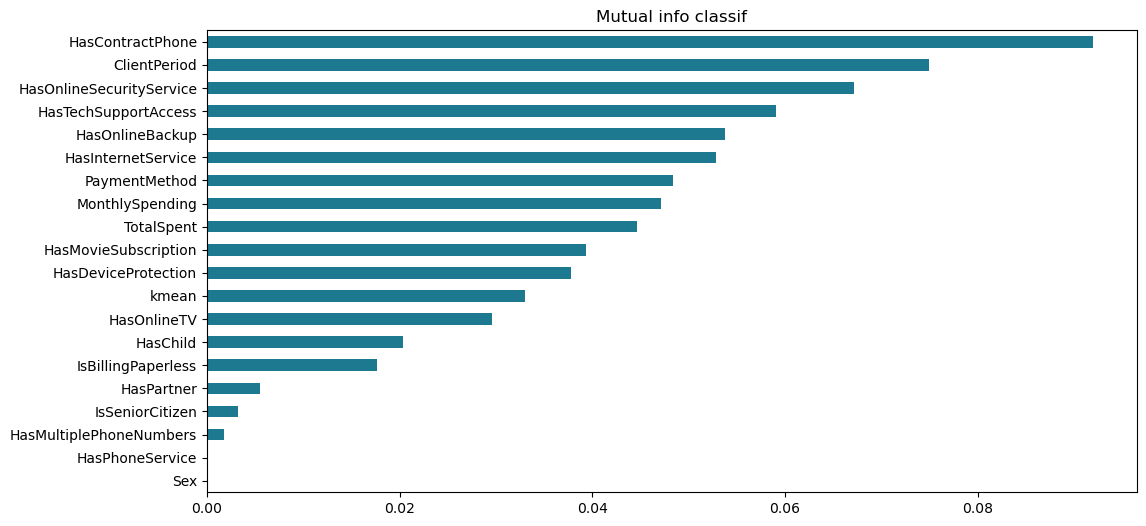

In [30]:
X = train.copy()
y = X.pop('Churn')

for col in list(X.select_dtypes(include=['object']).columns):
    X[col], _ = X[col].factorize()
scores = pd.Series(mutual_info_classif(X, y), index=X.columns).sort_values()
scores.plot(kind='barh', figsize = (12,6), color=palitra['blue'])
plt.title('Mutual info classif');

In [31]:
# удалим признак TotalSpent из наших выборок, т.к. имеем сильную линейную корреляцию
train = train.drop(['TotalSpent'], axis=1)
test = test.drop(['TotalSpent'], axis=1)

# этот список для удаления получился в результате подбора моделеей и проверки важности признаков
unimportant_cols =  ['HasPartner', 'HasDeviceProtection', 'Sex']
train = train.drop(unimportant_cols, axis=1)
test = test.drop(unimportant_cols, axis=1)

## <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 25px 5px;">3. Datasets creation</p>

In [32]:
train_df = make_features(train)
test_df = make_features(test)
X_df = train_df.drop('Churn', axis=1)
y_df = train_df[['Churn']]
X_df.shape, test_df.shape

((5268, 16), (1761, 16))

In [33]:
test_df.head()

,ClientPeriod,MonthlySpending,IsSeniorCitizen,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,kmean
0,42,56.10,0,0,1,1,0,1,0,0,0,0,1,0,1,0
1,29,98.50,1,0,1,1,1,0,0,0,1,1,0,1,2,1
2,9,76.25,0,0,1,1,1,0,0,0,0,0,0,1,2,1
3,67,74.00,0,1,1,1,0,1,1,1,1,0,2,0,1,0
4,71,20.10,0,1,1,0,2,0,0,0,0,0,2,0,0,0


In [34]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5268 entries, 0 to 5281
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5268 non-null   int64  
 1   MonthlySpending           5268 non-null   float64
 2   IsSeniorCitizen           5268 non-null   int64  
 3   HasChild                  5268 non-null   int64  
 4   HasPhoneService           5268 non-null   int64  
 5   HasMultiplePhoneNumbers   5268 non-null   int64  
 6   HasInternetService        5268 non-null   int8   
 7   HasOnlineSecurityService  5268 non-null   int64  
 8   HasOnlineBackup           5268 non-null   int64  
 9   HasTechSupportAccess      5268 non-null   int64  
 10  HasOnlineTV               5268 non-null   int64  
 11  HasMovieSubscription      5268 non-null   int64  
 12  HasContractPhone          5268 non-null   int8   
 13  IsBillingPaperless        5268 non-null   int64  
 14  PaymentM

In [35]:
models_results = {
            'model': [],
            'rocauc_val': [],
            'params': []}

## <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 25px 5px;">4. Selection of models</p>

In [36]:
X_df_pl = make_my_pipline(X_df)
X_test_pl = make_my_pipline(test_df)
X_train, X_val, y_train, y_val = train_test_split(X_df_pl, y_df, test_size=.25, random_state=SEED)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((3951, 16), (1317, 16), (3951, 1), (1317, 1))

In [37]:
X_train.head()

,ClientPeriod,MonthlySpending,IsSeniorCitizen,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,kmean
3295,0.184215,0.081942,-0.435856,-0.662237,0.331291,1.158159,-1.188551,1.563774,1.382789,1.558030,-0.795602,-0.801339,0.369088,-1.214728,0.405243,0.880982
4694,-0.549734,-1.329909,-0.435856,1.510033,-3.018497,-0.863439,-1.188551,-0.639479,-0.723176,-0.641836,-0.795602,-0.801339,-0.826704,0.823230,1.343627,0.880982
4330,1.040488,0.700041,-0.435856,-0.662237,0.331291,1.158159,-1.188551,1.563774,1.382789,-0.641836,1.256910,1.247911,1.564881,0.823230,0.405243,-1.135097
5193,-1.039033,-0.181538,-0.435856,-0.662237,0.331291,-0.863439,-1.188551,-0.639479,-0.723176,1.558030,1.256910,-0.801339,-0.826704,0.823230,1.343627,0.880982
4690,0.306539,-1.502248,-0.435856,-0.662237,0.331291,-0.863439,1.530792,-0.639479,-0.723176,-0.641836,-0.795602,-0.801339,1.564881,-1.214728,-0.533140,-1.135097


### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">4.1. Catboost</p>

In [38]:
# def objective(trial):
    
#     params = {
#         'eval_metric': 'AUC',
#         'random_state': SEED,
#         'learning_rate': trial.suggest_float('learning_rate', 0.00001, 0.1, step=0.00001),
#         'depth': trial.suggest_int('depth', 1, 16), 
#         'iterations' : trial.suggest_int('iterations', 10, 1000, step=10),
#         'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 8)
#     }   
#     # создаем и обучаем модель с мониторингом переобучения
#     model = CatBoostClassifier(**params, auto_class_weights='Balanced')      
#     model.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
#     preds = model.predict(X_val)  
    
#     return roc_auc_score(y_val, preds)

In [39]:
# %%time
# study = optuna.create_study(direction='maximize')  
# study.optimize(objective, n_trials=20)              
# # смотрим на финальные метрики
# print('Number of finished trials:', len(study.trials))
# print('Best trial:', study.best_trial.params)
# print('Best score:', study.best_trial.value)

In [40]:
# plot_param_importances(study)

In [41]:
# study.best_params

In [42]:
# optuna_params = study.best_params
# optuna_params['random_state'] = SEED
# optuna_params['eval_metric'] = 'AUC'
# optuna_params

In [43]:
PARAMS = {"n_estimators": 250, "learning_rate": 0.05, "max_depth": 4, "l2_leaf_reg": 10, "subsample": 0.6, 
          "random_strength": 5, "min_data_in_leaf": 100}

In [44]:
# optuna_params = {'learning_rate': 0.1, 'depth': 2, 'iterations': 490, 'l2_leaf_reg': 5, 'random_state': 202301, 'eval_metric': 'AUC'}
optuna_params = {'learning_rate': 0.02603, 'depth': 3, 'iterations': 680, 'l2_leaf_reg': 3, 'random_state': 202301, 'eval_metric': 'AUC'}

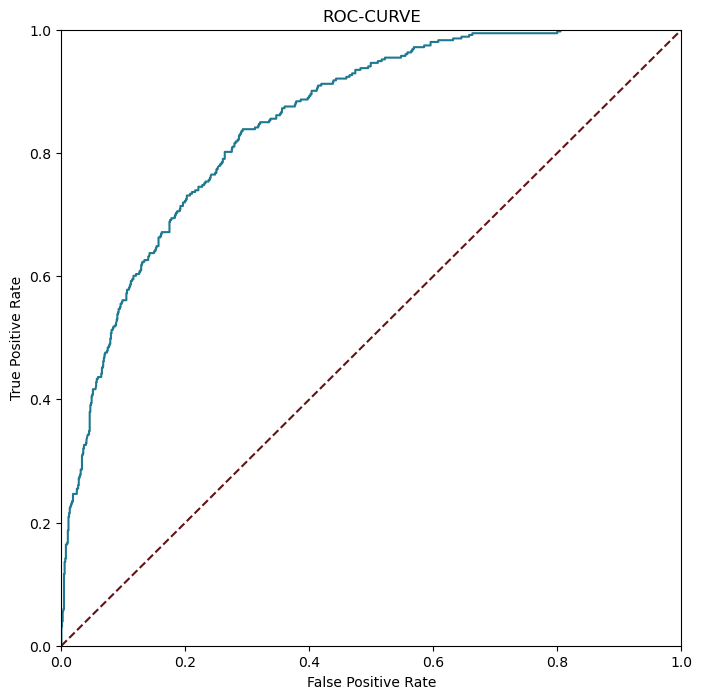

ROC-AUC: 0.851765542534059


In [45]:
best_cbc = CatBoostClassifier(**PARAMS, auto_class_weights='Balanced')
best_cbc.fit(X_train, y_train, eval_set=[(X_val,y_val)], early_stopping_rounds=300, verbose=False)
pred_prob = best_cbc.predict_proba(X_val)[:,1]

models_results['rocauc_val'].append(roc_auc_score(y_val, pred_prob))
models_results['model'].append('Catboost')
models_results['params'].append(optuna_params)

make_roc_curve(y_val, pred_prob)

In [46]:
cbc = pd.DataFrame({
    'feature_name': best_cbc.feature_names_,
    'feature_score': best_cbc.feature_importances_
}).sort_values('feature_score', ascending=False).reset_index(drop=True)

cbc.style.background_gradient(low=0.1, cmap='YlOrRd')

,feature_name,feature_score
0,HasContractPhone,29.854264
1,ClientPeriod,20.682125
2,MonthlySpending,11.585831
3,HasInternetService,10.910712
4,PaymentMethod,6.940604
5,IsBillingPaperless,4.975505
6,HasOnlineSecurityService,2.413565
7,HasMovieSubscription,2.053045
8,kmean,2.012139
9,HasTechSupportAccess,1.936691


### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">4.2. LGBM</p>

In [47]:
# fit_params = dict(early_stopping_rounds = 20,
#                   eval_set = [(X_train, y_train), (X_val, y_val)], 
#                   eval_metric='AUC',
#                   verbose = 1000)
# params = {'n_estimators': range(10, 1001, 10),
#           'learning_rate': [0.01, 0.05, 0.1],
#           'max_depth': range(-1, 17, 1),
#           'num_leaves': range(1, 200, 1)     
#          }
# lgbm = LGBMClassifier(random_state=SEED, class_weight='balanced')
# grid_lgbm = RandomizedSearchCV(lgbm, params, scoring='roc_auc', cv=5)
# grid_lgbm.fit(X_train, y_train, **fit_params)
# grid_lgbm.best_params_

In [48]:
# best_lgb = LGBMClassifier(**grid_lgbm.best_params_, class_weight='balanced', random_state=SEED)
# best_lgb.fit(X_train, y_train, verbose=False)
# pred_prob = best_lgb.predict_proba(X_val)[:,1]

# models_results['rocauc_val'].append(roc_auc_score(y_val, pred_prob))
# models_results['model'].append('LGBM')
# models_results['params'].append(optuna_params)

# make_roc_curve(y_val, pred_prob)

In [49]:
# lgb = pd.DataFrame({
#     'feature_name': best_lgb.feature_name_,
#     'feature_score': best_lgb.feature_importances_
# }).sort_values('feature_score', ascending=False).reset_index(drop=True)

# lgb.style.background_gradient(low=0.1, cmap='YlOrRd')

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">4.3. XGBoost</p>

In [50]:
# fit_params = dict(early_stopping_rounds = 20,
#                   eval_set = [(X_train, y_train), (X_val, y_val)], 
#                   eval_metric='AUC',
#                   verbose = 1000)
# params = {'n_estimators': range(10, 1001, 10),
#           'learning_rate': [0.01, 0.05, 0.1],
#           'max_depth': range(-1, 17, 1),
#           'num_leaves': range(1, 200, 1),
#           'boosting_type': ['gbdt', 'dart', 'goss']       
#          }
# xgb = XGBClassifier(random_state=SEED, class_weight='balanced')
# grid_xgb = RandomizedSearchCV(xgb, params, scoring='roc_auc', cv=5)
# grid_xgb.fit(X_train, y_train, **fit_params)
# grid_xgb.best_params_

In [51]:
# best_xgb = XGBClassifier(**grid_xgb.best_params_, class_weight='balanced', random_state=SEED)
# best_xgb.fit(X_train, y_train, verbose=False)
# pred_prob = best_xgb.predict_proba(X_val)[:,1]

# models_results['rocauc_val'].append(roc_auc_score(y_val, pred_prob))
# models_results['model'].append('XGBClassifier')
# models_results['params'].append(optuna_params)

# make_roc_curve(y_val, pred_prob)

In [52]:
# feature_important = best_xgb.get_booster().get_score(importance_type='weight')
# keys = list(feature_important.keys())
# values = list(feature_important.values())

# xgb = pd.DataFrame(data=values, index=keys, columns=['score']).sort_values(by='score')
# xgb.plot(kind='barh', figsize = (18,12), color=palitra['blue']);

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">4.4. LogisticRegression</p>

In [53]:
# lr = LogisticRegression(random_state=SEED)
# lr.fit(X_train, y_train)
# pred_prob = lr.predict_proba(X_val)[:,1]

# models_results['rocauc_val'].append(roc_auc_score(y_val, pred_prob))
# models_results['model'].append('LogisticRegression')
# models_results['params'].append(optuna_params)

# make_roc_curve(y_val, pred_prob)

### <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:120%; text-align:left; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 5px 5px;">4.5. Ensemble</p>

In [54]:
# best_cbc.fit(X_train, y_train, verbose=False)
# best_lgb.fit(X_train, y_train, verbose=False)
# best_xgb.fit(X_train, y_train, verbose=False)
# lr.fit(X_train, y_train)

# ens_pred_prob = np.column_stack([best_cbc.predict_proba(X_val)[:,1], 
#                                  best_lgb.predict_proba(X_val)[:,1],
#                                  best_xgb.predict_proba(X_val)[:,1],
#                                  lr.predict_proba(X_val)[:,1]]
#                                ).mean(axis=1)
# models_results['rocauc_val'].append(roc_auc_score(y_val, ens_pred_prob))
# models_results['model'].append(f'Ensemble')
# models_results['params'].append('unknown')

In [55]:
# make_roc_curve(y_val, ens_pred_prob)

## <p style="background-color:#641216; font-family:Nexa; color:#e8f8f5; font-size:150%; text-align:center; border: 2.5px; border-style:solid; border-color:#210400; border-radius: 25px 5px;">5. Best Model Submission</p>

In [56]:
pd.DataFrame(data=models_results).sort_values(by='rocauc_val', ascending=False).style.background_gradient(low=0.1, cmap='YlOrRd')

,model,rocauc_val,params
0,Catboost,0.851766,"{'learning_rate': 0.02603, 'depth': 3, 'iterations': 680, 'l2_leaf_reg': 3, 'random_state': 202301, 'eval_metric': 'AUC'}"


In [57]:
# обучим модель на всех данных
best_cbc.fit(X_df_pl, y_df, verbose=False)

# сделаем предсказания на тестовых данных
submission['Churn'] = best_cbc.predict_proba(X_test_pl)[:, 1] 

# запишем предсказания
submission.to_csv('submission.csv', index = False)

In [58]:
submission

,Id,Churn
0,0,0.138238
1,1,0.844269
2,2,0.849425
3,3,0.031848
4,4,0.013276
...,...,...
1756,1756,0.304249
1757,1757,0.009987
1758,1758,0.923900
1759,1759,0.785312
